Task 1: Load and Inspect **Data**

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [ ]:
import os
print(os.listdir())

['.config', 'netflix_titles (1).csv', 'netflix_titles.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

1. The Netflix dataset contains 8,807 records and 12 features describing movies and TV shows available on the platform.
2. The dataset includes Show ID, Type, Title, Director, Cast, Country, Date Added, Release Year, Rating, Duration, Listed In, and Description.
3. Data inspection revealed missing values in the Director (2634), Cast (825), Country (831), Date Added (10), Rating (4), and Duration (3) columns.
4. The dataset contains content from various countries and across multiple release years, making it suitable for trend and content analysis.
5. No duplicate records were found, indicating that the dataset is well-structured and ready for further cleaning and exploration.

Task 2: Data **Cleaning**

In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Not Available')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


Data Cleaning Summary

1. Checked the dataset for duplicate records and found none.
2. Replaced missing values in the Director column with 'Unknown'.
3. Replaced missing values in the Cast and Country columns with 'Unknown'.
4. Filled missing values in Date Added with 'Not Available'.
5. Replaced missing values in Rating and Duration with 'Unknown' to maintain data consistency.

Task 3: Exploratory Data **Analysis**

### Question 1: What is the distribution of Movies and TV Shows on Netflix?

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


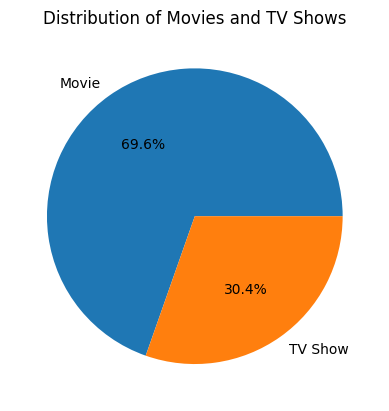

In [ ]:
df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Distribution of Movies and TV Shows')
plt.ylabel('')
plt.show()

Insight:
Approximately 70% of Netflix's content consists of movies, while TV shows account for about 30%. This suggests that Netflix focuses more heavily on movie content than television series.

### Question 2: Which countries contribute the most content to Netflix?

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

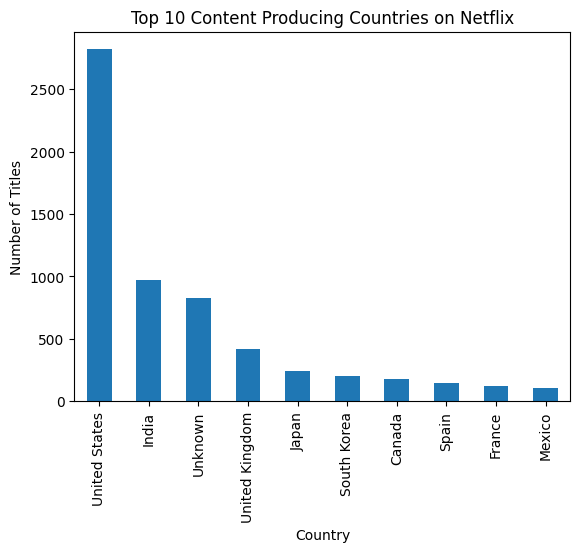

In [ ]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content Producing Countries on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

Insight
The United States contributes the highest number of titles, followed by India.

Question 3: What are the most common content ratings on Netflix?

In [ ]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


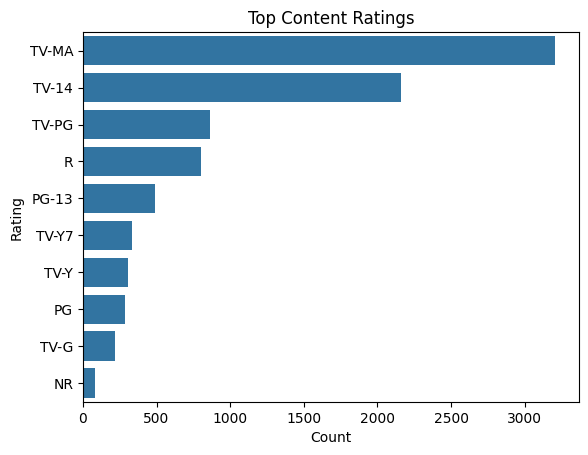

In [ ]:
import seaborn as sns

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index[:10]
)
plt.title('Top Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

Insight
TV-MA and TV-14 are the most common ratings, indicating a strong focus on mature and teenage audiences.

Question 4: How has Netflix content been released over the years?

In [ ]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


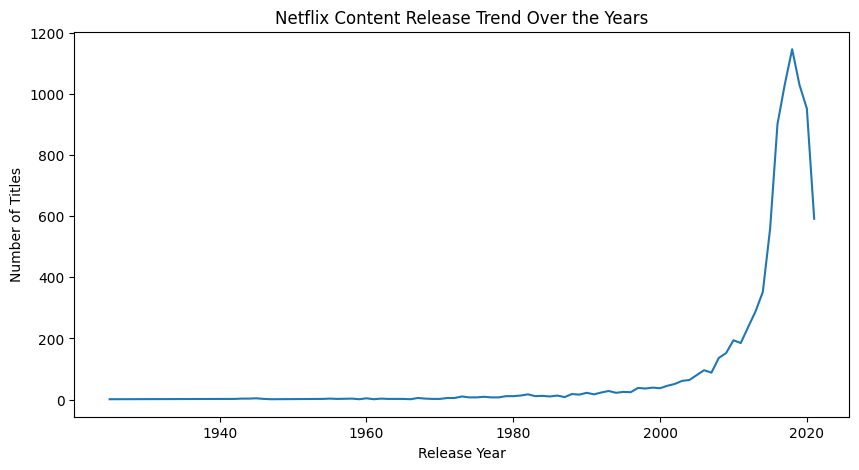

In [ ]:
df['release_year'].value_counts().sort_index().plot(figsize=(10,5))
plt.title('Netflix Content Release Trend Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

Insight
Netflix content increased rapidly after 2015 and peaked around 2018.

Question 5: Who are the most frequent directors on Netflix?

In [ ]:
df['director'].value_counts().head(10)

,count
director,
Unknown,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


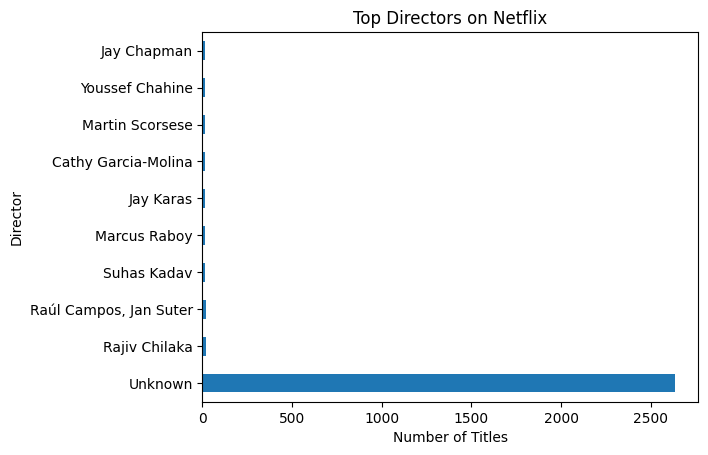

In [ ]:
df['director'].value_counts().head(10).plot(kind='barh')
plt.title('Top Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

Insight
Rajiv Chilaka appears most frequently among identified directors, while many records have missing director information.

Question 6: What is the distribution of release years?

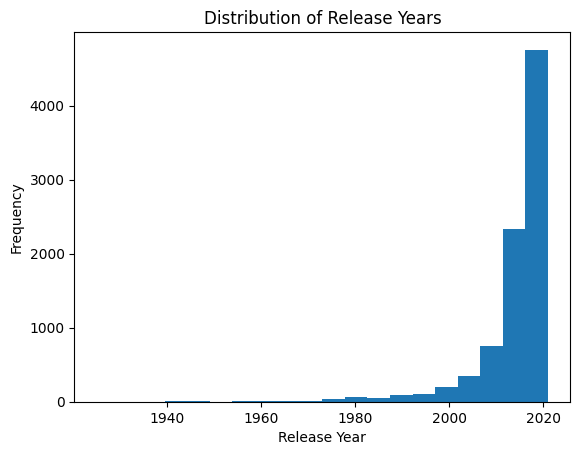

In [ ]:
df['release_year'].plot(kind='hist', bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

Insight
Most Netflix titles in the dataset were released in recent years, with relatively few older titles.

Task 5: Insights Report

1. Based on the Pie Chart showing the distribution of content types, Movies account for approximately 70% of Netflix's catalog (6,131 titles), while TV Shows account for about 30% (2,676 titles). This indicates that Netflix places a stronger emphasis on movie content.

2. According to the Bar Chart of the Top 10 Content Producing Countries, the United States contributes the highest number of titles (2,818), followed by India (972). This suggests that these two countries play a major role in Netflix's global content library.

3. The Ratings Distribution Chart shows that TV-MA (3,207 titles) and TV-14 (2,160 titles) are the most common ratings on Netflix. This indicates that a large portion of the platform's content is targeted toward mature and teenage audiences.

4. The Line Chart illustrating content releases by year reveals a significant increase in content production after 2015, with the highest number of releases recorded in 2018 (1,147 titles). This reflects Netflix's rapid expansion and investment in content during that period.

5. The Top Directors Chart shows that Rajiv Chilaka has the highest number of titles among identified directors (19 titles). However, the large number of records categorized as "Unknown" suggests that missing director information may affect detailed director-level analysis.